# Visualize Segmentations

This notebook loads images and YOLO-format segmentation labels from `dataset_out` and overlays polygons for quick inspection.


In [44]:
# Imports and configuration
from pathlib import Path
import json
import random
from typing import Dict, List, Tuple

import numpy as np
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

# Paths
ROOT = Path('/Users/wladyslaw/Documents/Job/LCT/additional_aero_tools_generator')
DATASET_DIR = ROOT / 'dataset_out'
IMAGES_DIR = DATASET_DIR / 'images'
SEGM_DIR = DATASET_DIR / 'labels_cls30'
CLASS_MAP_PATH = DATASET_DIR / 'class_mapping.json'

assert IMAGES_DIR.exists(), f"Missing images dir: {IMAGES_DIR}"
assert SEGM_DIR.exists(), f"Missing seg labels dir: {SEGM_DIR}"

with open(CLASS_MAP_PATH, 'r') as f:
    CLASS_MAP: Dict[str, str] = json.load(f)

# Build reverse mapping id->name and name->id
CLASS_ID_TO_NAME: Dict[int, str] = {int(k): v for k, v in CLASS_MAP.items()}
CLASS_NAME_TO_ID: Dict[str, int] = {v: int(k) for k, v in CLASS_MAP.items()}

# Toggle for compact label styling (smaller text/boxes)
SMALL_LABELS: bool = True

print(f"Loaded {len(CLASS_ID_TO_NAME)} classes")


Loaded 57 classes


In [45]:
# Parsing utilities for YOLO segmentation labels (robust to class names and comments)

def _normalize_class_token(token: str) -> str:
    token = token.strip()
    # Drop directories
    if '/' in token or '\\' in token:
        token = token.replace('\\', '/').split('/')[-1]
    # Drop common image extensions if present
    for ext in ('.jpg', '.jpeg', '.png', '.webp', '.bmp', '.tif', '.tiff'):
        if token.lower().endswith(ext):
            token = token[: -len(ext)]
            break
    return token


def _ensure_class_id(class_token: str) -> int:
    """Return class id for token. Accepts numeric ids or class names.
    If a new class name is encountered that's not in CLASS_NAME_TO_ID,
    allocate a new id in-memory so coloring and labels stay consistent.
    """
    token = _normalize_class_token(class_token)
    # Try numeric first
    try:
        return int(float(token))
    except ValueError:
        pass

    # Try known name mapping
    if token in CLASS_NAME_TO_ID:
        return CLASS_NAME_TO_ID[token]

    # Allocate a new id for unseen class name (session-local)
    new_id = (max(CLASS_ID_TO_NAME.keys()) + 1) if CLASS_ID_TO_NAME else 0
    CLASS_NAME_TO_ID[token] = new_id
    CLASS_ID_TO_NAME[new_id] = token
    return new_id


def parse_yolo_segmentation_label_line(line: str) -> Tuple[int, np.ndarray]:
    """Parse a single line of a YOLO-seg label file.
    Supports either numeric class ids or class names, and strips inline comments starting with '#'.
    Format: <cls_or_name> x1 y1 x2 y2 ... (normalized [0,1])
    Returns: (class_id, polygon as Nx2 ndarray)
    """
    # Strip inline comments
    core = line.split('#', 1)[0].strip()
    if not core:
        raise ValueError("Empty/Comment-only segmentation line")

    parts = core.split()
    if len(parts) < 3:
        raise ValueError(f"Malformed segmentation line: {line}")

    class_id = _ensure_class_id(parts[0])

    # Safely parse coords; ignore any trailing non-numeric just in case
    coords: List[float] = []
    for tok in parts[1:]:
        try:
            coords.append(float(tok))
        except ValueError:
            break

    if len(coords) < 6:
        # Not enough points for a polygon, but keep graceful behavior
        return class_id, np.zeros((0, 2), dtype=np.float32)

    if len(coords) % 2 != 0:
        coords = coords[:-1]

    polygon = np.asarray(coords, dtype=np.float32).reshape(-1, 2)
    return class_id, polygon


def load_segmentation_file(label_path: Path) -> List[Tuple[int, np.ndarray]]:
    """Load a YOLO segmentation label file and return list of (class_id, polygon)."""
    if not label_path.exists():
        return []
    segments: List[Tuple[int, np.ndarray]] = []
    with open(label_path, 'r') as f:
        for raw in f:
            # Remove comments and whitespace-only lines
            raw = raw.split('#', 1)[0].strip()
            if not raw:
                continue
            try:
                cls_id, poly = parse_yolo_segmentation_label_line(raw)
            except ValueError:
                continue
            segments.append((cls_id, poly))
    return segments


def yolo_to_pixel_polygon(polygon01: np.ndarray, width: int, height: int) -> np.ndarray:
    """Convert normalized [0,1] polygon coordinates into pixel coordinates."""
    if polygon01.size == 0:
        return polygon01
    px = np.copy(polygon01)
    px[:, 0] = np.clip(px[:, 0] * width, 0, width - 1)
    px[:, 1] = np.clip(px[:, 1] * height, 0, height - 1)
    return px.astype(np.float32)


def find_image_and_label_pairs(images_dir: Path, labels_dir: Path) -> List[Tuple[Path, Path]]:
    """Pairs images with their corresponding segmentation txt label files."""
    pairs: List[Tuple[Path, Path]] = []
    for img_path in sorted(images_dir.iterdir()):
        if not img_path.is_file():
            continue
        if img_path.suffix.lower() not in {'.jpg', '.jpeg', '.png', '.webp'}:
            continue
        stem = img_path.stem
        label_path = labels_dir / f"{stem}.txt"
        pairs.append((img_path, label_path))
    return pairs

pairs = find_image_and_label_pairs(IMAGES_DIR, SEGM_DIR)
print(f"Found {len(pairs)} image/label pairs")


Found 717 image/label pairs


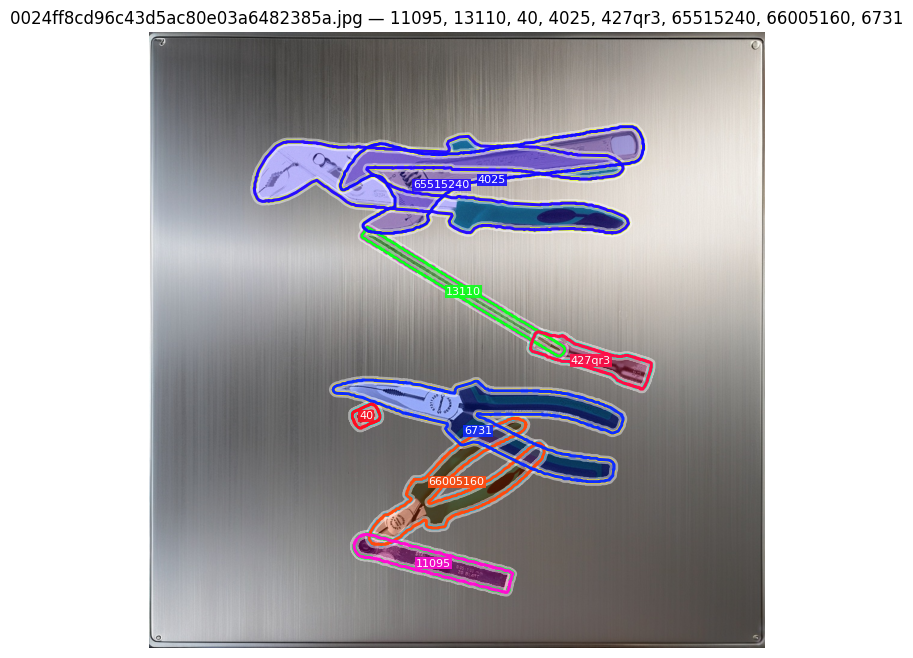

In [46]:
# Visualization helpers

from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
from matplotlib.colors import hsv_to_rgb


def vivid_color_for_class(class_id: int) -> Tuple[float, float, float]:
    # Bright, high-saturation HSV palette mapped by class id
    hue = (class_id * 0.137) % 1.0
    sat = 0.95
    val = 1.0
    r, g, b = hsv_to_rgb([hue, sat, val])
    return (float(r), float(g), float(b))


def complement_color_for_class(class_id: int) -> Tuple[float, float, float]:
    hue = ((class_id * 0.137) + 0.5) % 1.0
    r, g, b = hsv_to_rgb([hue, 0.9, 1.0])
    return (float(r), float(g), float(b))


def draw_segments_on_axes(ax, image_np: np.ndarray, segments: List[Tuple[int, np.ndarray]]):
    ax.imshow(image_np)
    h_img, w_img = image_np.shape[0], image_np.shape[1]

    patches: List[MplPolygon] = []
    face_colors: List[Tuple[float, float, float]] = []
    edge_colors_main: List[Tuple[float, float, float]] = []
    edge_colors_comp: List[Tuple[float, float, float]] = []

    for cls_id, poly_px in segments:
        if poly_px.shape[0] < 3:
            continue
        patches.append(MplPolygon(poly_px, closed=True))
        fc = vivid_color_for_class(cls_id)
        face_colors.append(fc)
        edge_colors_main.append(fc)
        edge_colors_comp.append(complement_color_for_class(cls_id))

    if patches:
        # Soft fill
        coll_fill = PatchCollection(patches, facecolor=face_colors, alpha=0.28, edgecolor='none')
        ax.add_collection(coll_fill)
        # Outer glow (white, thick, semi-transparent)
        coll_glow = PatchCollection(patches, facecolor='none', edgecolor='white', linewidths=6.0, alpha=0.45)
        ax.add_collection(coll_glow)
        # Complementary dashed outline
        coll_comp = PatchCollection(patches, facecolor='none', edgecolor=edge_colors_comp, linewidths=3.2, linestyles='dashdot', alpha=0.95)
        ax.add_collection(coll_comp)
        # Main vivid outline
        coll_edge = PatchCollection(patches, facecolor='none', edgecolor=edge_colors_main, linewidths=2.2, alpha=1.0)
        ax.add_collection(coll_edge)

    # Draw class labels; for class 0 place a big label above the polygon
    for cls_id, poly_px in segments:
        if poly_px.shape[0] < 3:
            continue
        x_min, y_min = np.min(poly_px, axis=0)
        x_max, y_max = np.max(poly_px, axis=0)
        cx, cy = (x_min + x_max) / 2.0, (y_min + y_max) / 2.0

        is_tool = (cls_id == 0)
        label_text = 'ИНСТРУМЕНТ' if is_tool else CLASS_ID_TO_NAME.get(cls_id, str(cls_id))
        # Position: above polygon for tools, centroid for others
        if is_tool:
            y_text = max(10, y_min - max(16, 0.03 * h_img))
            x_text = cx
            fontsize = 22 if not SMALL_LABELS else 12
            box_color = vivid_color_for_class(cls_id)
        else:
            y_text = cy
            x_text = cx
            fontsize = 10 if not SMALL_LABELS else 8
            box_color = vivid_color_for_class(cls_id)

        ax.text(
            x_text,
            y_text,
            label_text,
            fontsize=fontsize,
            color='white',
            ha='center',
            va='bottom' if is_tool else 'center',
            bbox=dict(facecolor=box_color, alpha=0.9, edgecolor='none', pad=(1.8 if not SMALL_LABELS else 0.8)),
        )

    ax.set_axis_off()


def render_sample(img_path: Path, label_path: Path):
    # Load image
    with Image.open(img_path) as im:
        im_rgb = im.convert('RGB')
        w, h = im_rgb.size
        image_np = np.array(im_rgb)

    # Load segments and convert to pixel coords
    raw_segments = load_segmentation_file(label_path)
    segments_px: List[Tuple[int, np.ndarray]] = []
    for cls_id, poly01 in raw_segments:
        poly_px = yolo_to_pixel_polygon(poly01, w, h)
        segments_px.append((cls_id, poly_px))

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    draw_segments_on_axes(ax, image_np, segments_px)
    title_names = []
    for cls, _ in raw_segments:
        name = 'ИНСТРУМЕНТ' if cls == 0 else CLASS_ID_TO_NAME.get(cls, str(cls))
        title_names.append(name)
    title_cls = ', '.join(sorted(set(title_names))) or 'no labels'
    ax.set_title(f"{img_path.name} — {title_cls}")
    plt.show()

# Quick sanity check on the first pair (if any)
if pairs:
    render_sample(*pairs[0])


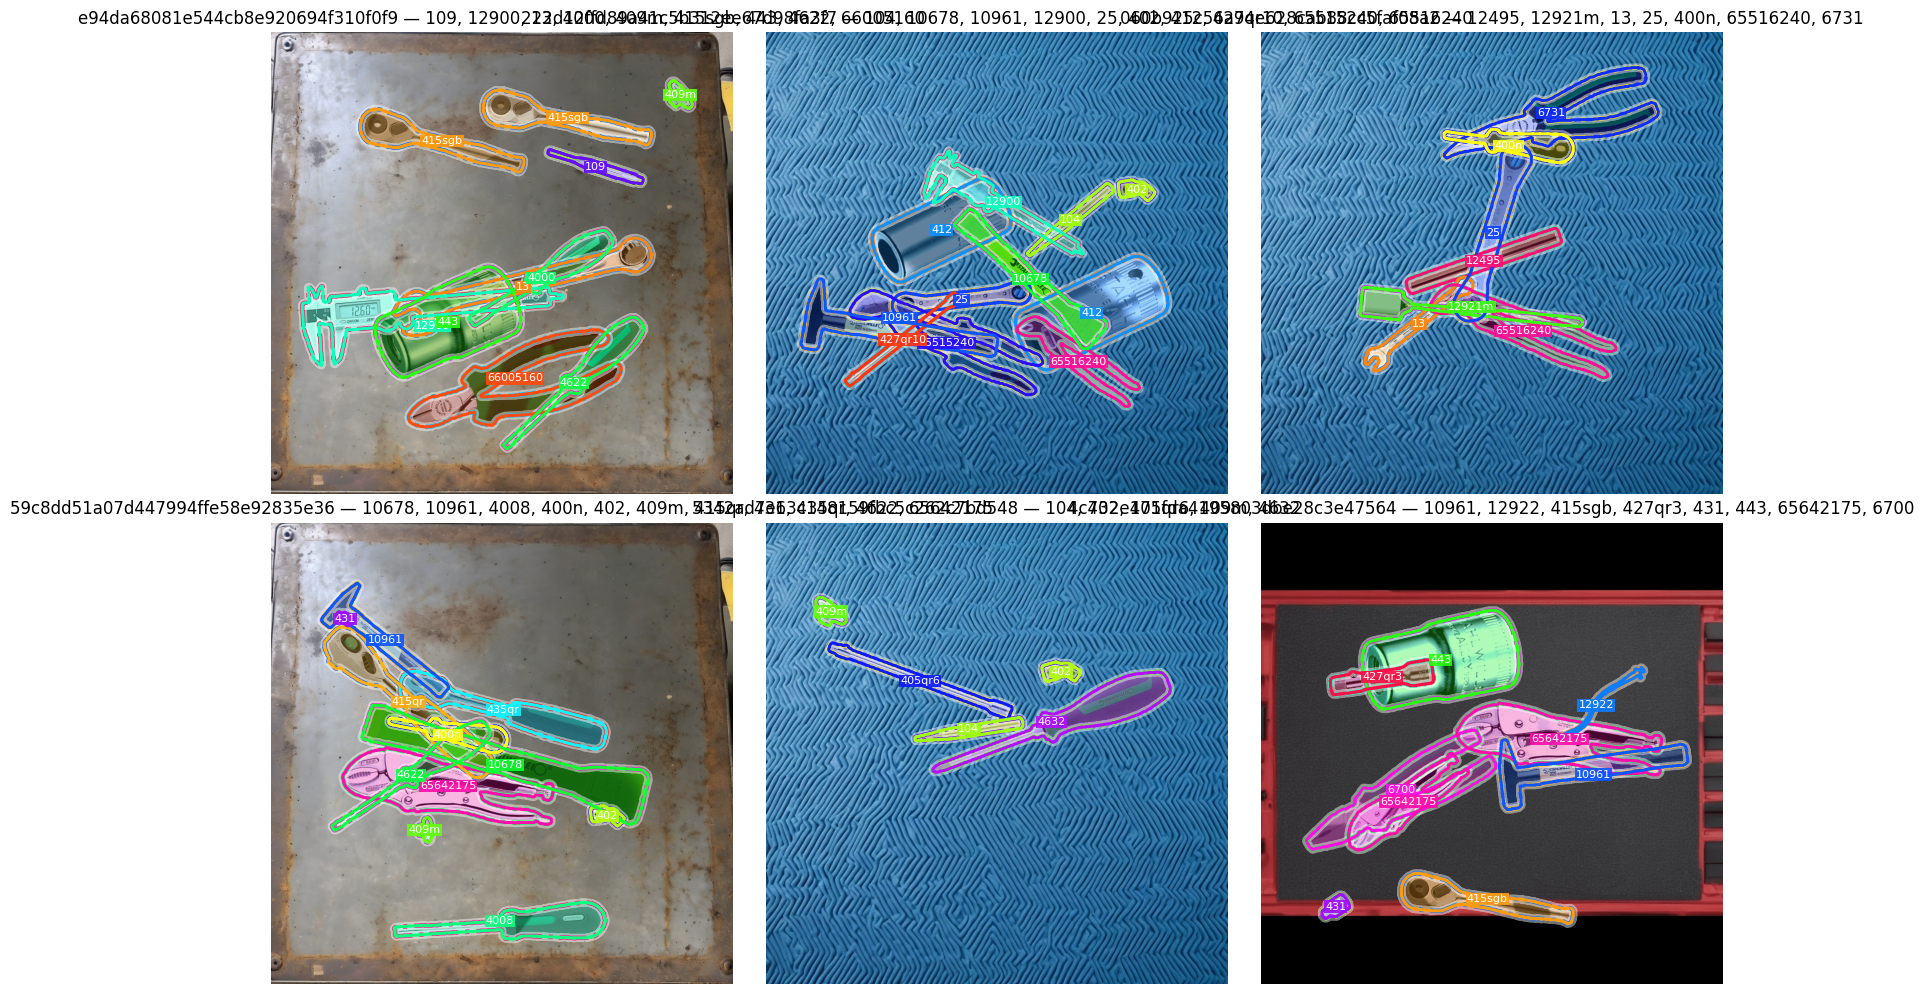

In [47]:
# Preview random grid

def preview_random_grid(pairs: List[Tuple[Path, Path]], n: int = 6, cols: int = 3, seed: int = 0):
    random.seed(seed)
    if not pairs:
        print("No pairs to preview")
        return
    sample = random.sample(pairs, k=min(n, len(pairs)))
    rows = int(np.ceil(len(sample) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
    if rows == 1 and cols == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = np.array([axes])
    axes = axes.reshape(rows, cols)

    for ax in axes.ravel():
        ax.set_axis_off()

    for idx, (img_path, label_path) in enumerate(sample):
        r, c = divmod(idx, cols)
        ax = axes[r, c]
        with Image.open(img_path) as im:
            im_rgb = im.convert('RGB')
            w, h = im_rgb.size
            image_np = np.array(im_rgb)
        raw_segments = load_segmentation_file(label_path)
        segments_px = [(cls_id, yolo_to_pixel_polygon(poly01, w, h)) for cls_id, poly01 in raw_segments]
        draw_segments_on_axes(ax, image_np, segments_px)
        names = []
        for cls, _ in raw_segments:
            names.append('ИНСТРУМЕНТ' if cls == 0 else CLASS_ID_TO_NAME.get(cls, str(cls)))
        classes = ', '.join(sorted(set(names))) or 'no labels'
        ax.set_title(f"{img_path.stem} — {classes}")

    plt.tight_layout()
    plt.show()

preview_random_grid(pairs, n=6, cols=3, seed=42)


In [48]:
# Save overlays (optional)

OUT_DIR = ROOT / 'dataset_out' / 'viz_overlays'
OUT_DIR.mkdir(parents=True, exist_ok=True)


def _rgb255(color: Tuple[float, float, float]) -> Tuple[int, int, int]:
    return (int(color[0] * 255), int(color[1] * 255), int(color[2] * 255))


def _get_font(px: int) -> ImageFont.FreeTypeFont:
    # Try TrueType for scalable text; fallback to default bitmap
    try:
        return ImageFont.truetype("DejaVuSans.ttf", px)
    except Exception:
        try:
            return ImageFont.truetype("Arial.ttf", px)
        except Exception:
            return ImageFont.load_default()


def save_overlay(img_path: Path, label_path: Path, out_path: Path, alpha: float = 0.28):
    with Image.open(img_path) as im:
        im_rgb = im.convert('RGB')
        w, h = im_rgb.size
        base = im_rgb.copy()
    raw_segments = load_segmentation_file(label_path)
    overlay = Image.new('RGBA', (w, h), (0, 0, 0, 0))
    draw = ImageDraw.Draw(overlay, 'RGBA')

    for cls_id, poly01 in raw_segments:
        poly_px = yolo_to_pixel_polygon(poly01, w, h)
        if poly_px.shape[0] < 3:
            continue
        main = _rgb255(vivid_color_for_class(cls_id))
        comp = _rgb255(complement_color_for_class(cls_id))

        # Soft fill
        fill_rgba = (main[0], main[1], main[2], int(255 * alpha))
        draw.polygon([tuple(pt) for pt in poly_px.tolist()], fill=fill_rgba)
        # Outer glow
        draw.line([tuple(pt) for pt in np.concatenate([poly_px, poly_px[:1]], axis=0)], fill=(255, 255, 255, int(255 * 0.45)), width=6)
        # Complementary dashed outline (approximate with short gaps)
        edge = np.concatenate([poly_px, poly_px[:1]], axis=0)
        for i in range(len(edge) - 1):
            x1, y1 = edge[i]
            x2, y2 = edge[i + 1]
            steps = max(4, int(np.hypot(x2 - x1, y2 - y1) / 8))
            for s in range(0, steps, 2):
                t0 = s / steps
                t1 = min(1.0, (s + 1) / steps)
                xi0 = x1 + (x2 - x1) * t0
                yi0 = y1 + (y2 - y1) * t0
                xi1 = x1 + (x2 - x1) * t1
                yi1 = y1 + (y2 - y1) * t1
                draw.line([(xi0, yi0), (xi1, yi1)], fill=(*comp, 255), width=3)
        # Main vivid outline
        draw.line([tuple(pt) for pt in np.concatenate([poly_px, poly_px[:1]], axis=0)], fill=(*main, 255), width=2)

        # Draw class label; for class 0 place big label above polygon
        x_min, y_min = np.min(poly_px, axis=0)
        x_max, y_max = np.max(poly_px, axis=0)
        cx, cy = (x_min + x_max) / 2.0, (y_min + y_max) / 2.0
        is_tool = (cls_id == 0)
        name = 'ИНСТРУМЕНТ' if is_tool else CLASS_ID_TO_NAME.get(cls_id, str(cls_id))

        # Dynamic font size and padding, respecting SMALL_LABELS
        if SMALL_LABELS:
            font_size = max(12, int((0.035 if is_tool else 0.024) * h))
            pad = max(4, int(0.25 * font_size))
        else:
            font_size = max(18, int((0.06 if is_tool else 0.032) * h))
            pad = max(6, int(0.35 * font_size))
        font = _get_font(font_size)

        # Measure text
        try:
            bbox = draw.textbbox((0, 0), name, font=font)
            tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
        except Exception:
            tw, th = draw.textsize(name, font=font)

        if is_tool:
            margin = max(12, int((0.015 if SMALL_LABELS else 0.02) * h))
            ty = int(y_min - th - pad - margin)
            tx = int(cx - tw / 2)
        else:
            ty = int(cy - th / 2)
            tx = int(cx - tw / 2)

        # Clamp inside image
        tx = max(0, min(tx, w - tw - 2))
        ty = max(0, min(ty, h - th - 2))

        box = main
        draw.rectangle([tx - pad, ty - pad, tx + tw + pad, ty + th + pad], fill=(box[0], box[1], box[2], int(255 * 0.9)))
        draw.text((tx, ty), name, font=font, fill=(255, 255, 255, 255))

    composed = Image.alpha_composite(base.convert('RGBA'), overlay)
    composed.convert('RGB').save(out_path)

# Example: save overlays for all pairs
for img_path, label_path in pairs:
    out_path = OUT_DIR / img_path.name
    save_overlay(img_path, label_path, out_path)
print(f"Saved {len(pairs)} overlays to {OUT_DIR}")


Saved 717 overlays to /Users/wladyslaw/Documents/Job/LCT/additional_aero_tools_generator/dataset_out/viz_overlays
